#Load Word2Vec Data

In [1]:
import numpy as np

X_train = np.load("X_train_w2v.npy")
X_val = np.load("X_val_w2v.npy")
X_test = np.load("X_test_w2v.npy")

y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (75000, 100) (75000,)
Validation: (44767, 100) (44767,)
Test: (89535, 100) (89535,)


#Import LSVM And Evaluation Metrics

In [2]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

#Hyperparameter Tuning

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import pandas as pd

C_values = [0.001, 0.01, 0.1, 1, 10]
results = []

for C in C_values:
    model = make_pipeline(
        StandardScaler(),
        LinearSVC(C=C, random_state=42)
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    results.append({
        "model": "LSVM",
        "features": "Word2Vec + Scaled",
        "C": C,
        "macro_f1": f1_score(y_val, y_val_pred, average="macro"),
        "weighted_f1": f1_score(y_val, y_val_pred, average="weighted"),
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision_macro": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_val_pred, average="macro", zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="macro_f1", ascending=False)
results_df

,model,features,C,macro_f1,weighted_f1,accuracy,precision_macro,recall_macro
0,LSVM,Word2Vec + Scaled,0.001,0.255936,0.419122,0.374383,0.266822,0.291960
1,LSVM,Word2Vec + Scaled,0.010,0.255582,0.419201,0.374338,0.266582,0.291260
2,LSVM,Word2Vec + Scaled,0.100,0.255580,0.419007,0.374115,0.266607,0.291224
3,LSVM,Word2Vec + Scaled,1.000,0.255510,0.419066,0.374160,0.266549,0.291100
4,LSVM,Word2Vec + Scaled,10.000,0.255444,0.419074,0.374160,0.266489,0.291002


#Pick The Best Hyperparameter(based on Macro F1 )

 Macro F1 is seleceted as the primary metric because the review score distribution is highly imbalanced, with a large majority of 5-star reviews. Macro F1 treats each class equally and therefore provides a more reliable measure of performance across all rating categories compared to accuracy or weighted metrics.

In [4]:
best_row = results_df.sort_values(by="macro_f1", ascending=False).iloc[0]
best_C = best_row["C"]

print("Best C:", best_C)
print(best_row)

Best C: 0.001
model                           LSVM
features           Word2Vec + Scaled
C                              0.001
macro_f1                    0.255936
weighted_f1                 0.419122
accuracy                    0.374383
precision_macro             0.266822
recall_macro                 0.29196
Name: 0, dtype: object


#Train The LSVM Model Using The Best Hyperparameter

In [5]:
final_model = LinearSVC(
    C=best_C,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

LinearSVC(C=np.float64(0.001), class_weight='balanced', random_state=42)

#Evaluate On The Test Set

In [6]:
y_test_pred = final_model.predict(X_test)

test_metrics = {
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0)
}

print(test_metrics)

{'macro_f1': 0.22030499005506138, 'weighted_f1': 0.41114590980351173, 'accuracy': 0.37579717428938403, 'precision_macro': 0.24105468451256423, 'recall_macro': 0.256690467535822}


In [7]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.14      0.40      0.21      8839
           2       0.08      0.25      0.12      4923
           3       0.10      0.05      0.07      6973
           4       0.18      0.10      0.13     12680
           5       0.70      0.49      0.57     56120

    accuracy                           0.38     89535
   macro avg       0.24      0.26      0.22     89535
weighted avg       0.49      0.38      0.41     89535



#Confusion Matrix

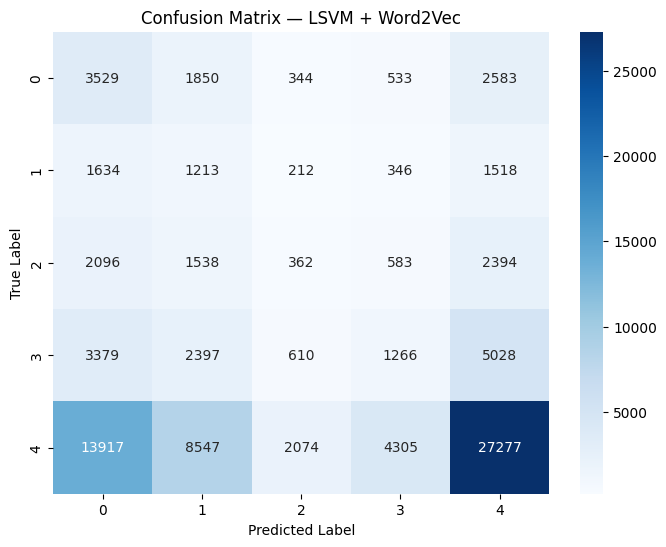

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — LSVM + Word2Vec")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Save The Results

###Validation Tuning Results

In [9]:
results_df.to_csv("results_lsvm_w2v_validation.csv", index=False)

###Final Test Result

In [10]:
final_results_df = pd.DataFrame([{
    "model": "LSVM",
    "features": "Word2Vec",
    "best_C": best_C,
    "macro_f1": test_metrics["macro_f1"],
    "weighted_f1": test_metrics["weighted_f1"],
    "accuracy": test_metrics["accuracy"],
    "precision_macro": test_metrics["precision_macro"],
    "recall_macro": test_metrics["recall_macro"]
}])

final_results_df.to_csv("results_lsvm_w2v_test.csv", index=False)

In this experiment, a Linear Support Vector Machine (LSVM) is trained using Average Word2Vec features. Hyperparameter tuning is performed by testing multiple values of the regularization parameter
𝐶
C on the balanced training set and selecting the best configuration based on validation Macro F1-score. The final selected model is then evaluated once on the untouched test set using Macro F1, Weighted F1, Accuracy, Precision, Recall, and a confusion matrix.

While Word2Vec captures semantic relationships between words, averaging embeddings across a review removes positional and contextual sentiment cues. This results in weaker performance for rating prediction compared to TF-IDF features, which preserve important lexical signals such as negation and sentiment-bearing terms.